# Ablation — Axe 1 : With vs Without Precedence

**Question :** Le precedence network améliore-t-il l'apprentissage ?

Compare baseline vs precedence (meilleure config) pour DQN et PPO sur CartPole et CliffWalking.

In [33]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
from ablation_utils import *


In [34]:
RUN_TRAINING = False

RUN_EVAL_100 = True
EVAL_N_REPORT = 100  

ENVS = ["CartPole-v1", "CliffWalking-v1"]
ALGOS = ["dqn", "ppo"]


In [35]:
results = {"entries": []}

for env in ENVS:
    for algo in ALGOS:
        base = load_baseline_metrics(algo, env)
        if base:
            base["env_name"] = env
            results["entries"].append(base)
            print(f"✓ baseline {algo} {env}: final={base['train_final_mean']:.1f} eval={base['eval_mean']:.1f}")
        else:
            print(f"⚠ baseline manquant: {algo} {env}")

        best_cfg = pick_best_wm_config(algo, env)
        prec = load_precedence_config(algo, env, best_cfg)
        if prec:
            prec["label"] = f"{algo.upper()}+prec (config{best_cfg})"
            results["entries"].append(prec)
            print(f"✓ precedence {algo} {env} cfg{best_cfg}: final={prec['train_final_mean']:.1f}")
        else:
            print(f"⚠ precedence manquant: {algo} {env}")

if RUN_TRAINING and "CartPole-v1" in ENVS:
    print("\nEntraînement DQN CartPole (baseline + precedence best)...")
    base_runs = run_multi_seed_cartpole(
        lambda seed, **kw: train_dqn_cartpole(seed=seed, use_precedence=False, **kw))
    prec_runs = run_multi_seed_cartpole(
        lambda seed, **kw: train_dqn_cartpole(seed=seed, use_precedence=True, wm_config=2, **kw))
    results["dqn_cartpole_baseline_trained"] = base_runs
    results["dqn_cartpole_precedence_trained"] = prec_runs


✓ baseline dqn CartPole-v1: final=327.3 eval=142.8
✓ precedence dqn CartPole-v1 cfg1: final=147.3
✓ baseline ppo CartPole-v1: final=500.0 eval=500.0
✓ precedence ppo CartPole-v1 cfg3: final=490.0
✓ baseline dqn CliffWalking-v1: final=-15.2 eval=-15.0
✓ precedence dqn CliffWalking-v1 cfg3: final=-14.1
✓ baseline ppo CliffWalking-v1: final=-4002.0 eval=-200.0
✓ precedence ppo CliffWalking-v1 cfg2: final=-13.0


## Figures

- **Train final mean** : performance en fin d'entraînement (bruit ε-greedy / PPO encore présent).
- **Greedy eval (100 eps)** : politique figée (argmax Q / argmax logits), comparable à `evaluate_agent_greedy` du notebook DQN full — **métrique recommandée pour l'ablation**.


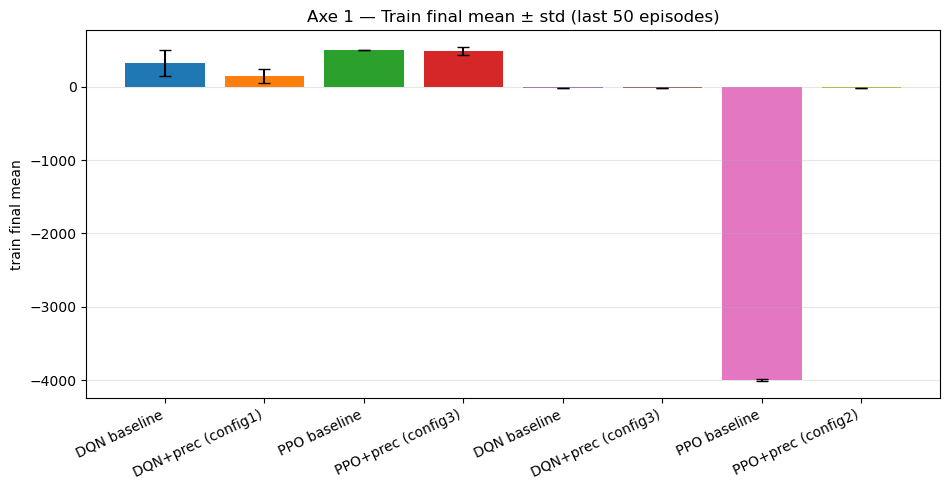

📊 /Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/ABLATION STUDY/plots/ablation_with_vs_without_train_bars.png

Greedy evaluation — 100 episodes per model...

✓ Eval 100 eps — DQN baseline: 225.08 ± 102.99 (success 1%)
✓ Eval 100 eps — DQN+prec (config1): 455.62 ± 70.87 (success 65%)
✓ Eval 100 eps — PPO baseline: 500.00 ± 0.00 (success 100%)
✓ Eval 100 eps — PPO+prec (config3): 484.59 ± 27.82 (success 70%)
✓ Eval 100 eps — DQN baseline: -15.00 ± 0.00 (success 100%)
✓ Eval 100 eps — DQN+prec (config3): -15.00 ± 0.00 (success 100%)
✓ Eval 100 eps — PPO baseline: -200.00 ± 0.00 (success 0%)
✓ Eval 100 eps — PPO+prec (config2): -13.00 ± 0.00 (success 100%)


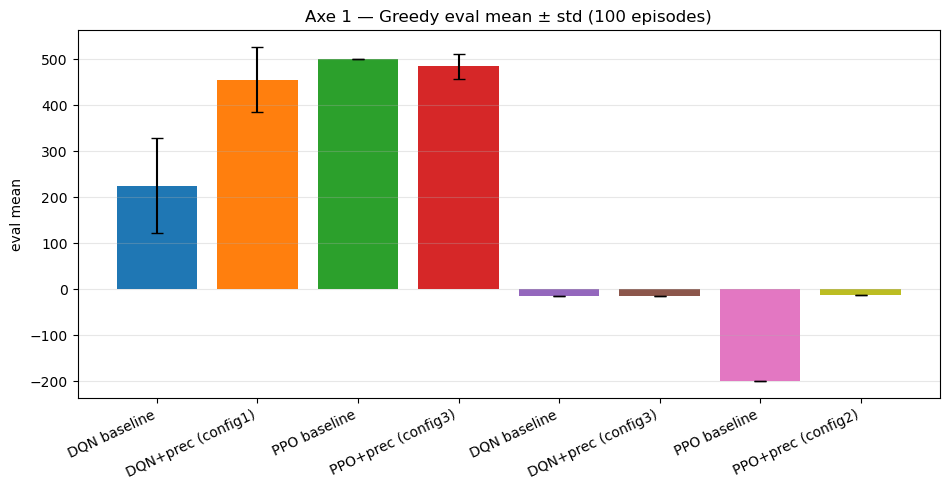

📊 /Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/ABLATION STUDY/plots/ablation_with_vs_without_eval100_bars.png


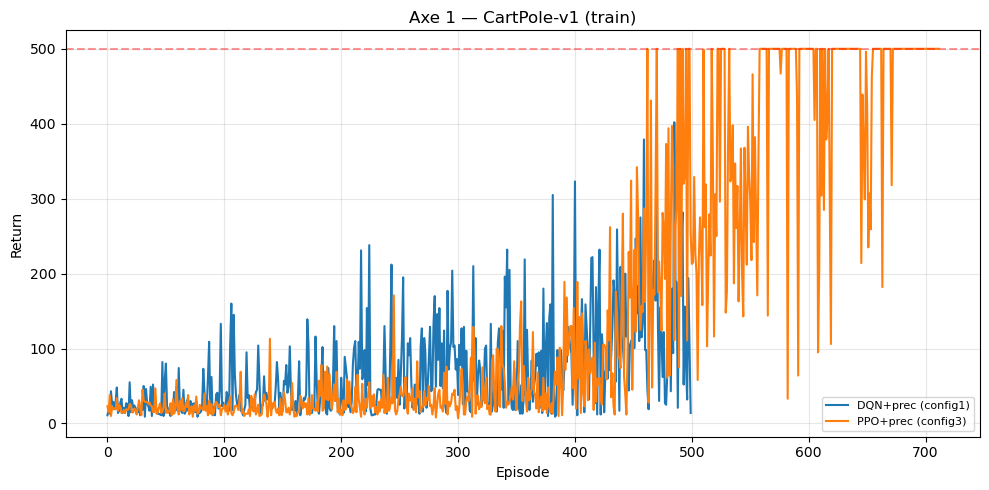

📊 /Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/ABLATION STUDY/plots/ablation_with_vs_without_CartPole_v1.png


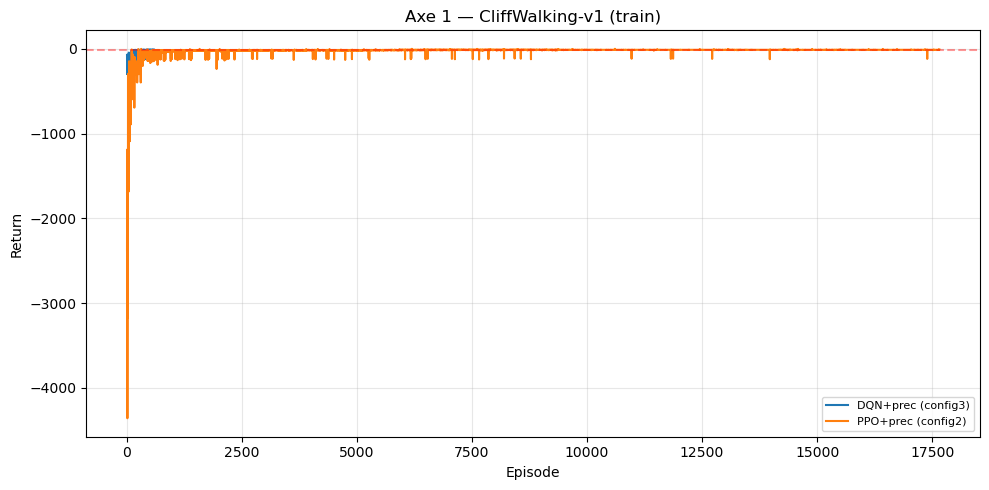

📊 /Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/ABLATION STUDY/plots/ablation_with_vs_without_CliffWalking_v1.png
✅ Saved → /Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/ABLATION STUDY/results/ablation_with_vs_without.json


PosixPath('/Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/ABLATION STUDY/results/ablation_with_vs_without.json')

In [36]:

plot_bar_comparison(
    results["entries"],
    title="Axe 1 — Train final mean ± std (last 50 episodes)",
    save_name="ablation_with_vs_without_train_bars.png",
    metric="train_final_mean",
)


if RUN_EVAL_100:
    print(f"\nGreedy evaluation — {EVAL_N_REPORT} episodes per model...\n")
    refresh_entries_greedy_eval(results["entries"], n_episodes=EVAL_N_REPORT)

plot_bar_comparison(
    results["entries"],
    title=f"Axe 1 — Greedy eval mean ± std ({EVAL_N_REPORT} episodes)",
    save_name="ablation_with_vs_without_eval100_bars.png",
    metric="eval_mean",
)


for env in ENVS:
    subset = [e for e in results["entries"] if e["env_name"] == env]
    curves = {
        e["label"]: {"reward_curves": [e.get("rewards", [])]}
        for e in subset if e.get("rewards")
    }
    if curves:
        plot_learning_curves(
            curves, f"Axe 1 — {env} (train)",
            f"ablation_with_vs_without_{env.replace('-', '_')}.png",
            solve_threshold=ENV_SPECS[env]["solve_threshold"],
        )

save_ablation_result("ablation_with_vs_without", results)
